In [50]:
import numpy as np
from scipy.spatial import Delaunay

In [51]:
points = np.array([[0, 0], [1, 1], [2, 2]])
tri = Delaunay(points)

QhullError: QH6154 Qhull precision error: Initial simplex is flat (facet 1 is coplanar with the interior point)

While executing:  | qhull d Qc Qbb Q12 Qz Qt
Options selected for Qhull 2020.2.r 2020/08/31:
  run-id 1828238041  delaunay  Qcoplanar-keep  Qbbound-last  Q12-allow-wide
  Qz-infinity-point  Qtriangulate  _pre-merge  _zero-centrum  Qinterior-keep
  Pgood  _max-width  2  Error-roundoff 2.8e-15  _one-merge 1.9e-14
  Visible-distance 5.5e-15  U-max-coplanar 5.5e-15  Width-outside 1.1e-14
  _wide-facet 3.3e-14  _maxoutside 2.2e-14

The input to qhull appears to be less than 3 dimensional, or a
computation has overflowed.

Qhull could not construct a clearly convex simplex from points:
- p1(v4):     1     1  0.45
- p3(v3):     1     1     2
- p2(v2):     2     2   1.8
- p0(v1):     0     0     0

The center point is coplanar with a facet, or a vertex is coplanar
with a neighboring facet.  The maximum round off error for
computing distances is 2.8e-15.  The center point, facets and

In [ ]:
tri.simplices

array([[2, 3, 0],
       [3, 1, 0]], dtype=int32)

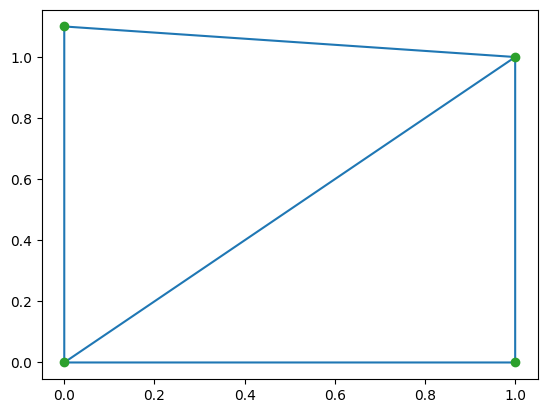

In [ ]:
import matplotlib.pyplot as plt
plt.triplot(points[:,0], points[:,1], tri.simplices)
plt.plot(points[:,0], points[:,1], 'o')
plt.show()

In [ ]:
points[tri.simplices]

array([[[1. , 0. ],
        [1. , 1. ],
        [0. , 0. ]],

       [[1. , 1. ],
        [0. , 1.1],
        [0. , 0. ]]])

In [ ]:
p = np.array([(0.1, 0.2), (1.5, 0.5), (0.5, 1.05)])

In [ ]:
tri.transform[1]

array([[ 1.        ,  0.        ],
       [-0.90909091,  0.90909091],
       [ 0.        ,  0.        ]])